# Cross-Era Music Analysis Screenshot Notebook

This notebook reproduces the key analysis views used in the IEEE progress report.
Run all cells in order, then capture screenshots for the report.

1. Data quality summary table
2. Top historical genres by revival count
3. Top Spotify genre buckets by total streams
4. Cross-era comparison chart (historical revival count vs modern streams share)
5. Concentration summary table

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (10, 5)

quality = pd.read_csv("../data/processed/spotify_data_quality_summary.csv")
spotify_genre = pd.read_csv("../data/processed/spotify_genre_summary.csv")
loc_genre = pd.read_csv("../data/processed/loc_genre_summary.csv")
cross = pd.read_csv("../data/processed/cross_era_genre_table.csv")
concentration = pd.read_csv("../data/processed/concentration_summary.csv")

print("Loaded:")
for name, df in {
    "quality": quality,
    "spotify_genre": spotify_genre,
}.items():
    print(name, df.shape)

Loaded:
quality (5, 2)
spotify_genre (9, 5)


In [5]:
# Screenshot 1: Data quality summary
quality

,metric,value
0,dataset1_rows_after_dedup,941.000000
1,dataset2_rows_after_dedup,5845.000000
2,merged_rows,941.000000
3,rows_with_genre_match,39.000000
4,genre_match_rate,0.041445


In [6]:
# Screenshot 2: Top historical genres by revival count
loc_top = loc_genre.sort_values("historical_genre_revival_count", ascending=False).head(10)
loc_top[["genre_bucket", "historical_genre_revival_count", "avg_revival_strength"]]

,genre_bucket,historical_genre_revival_count,avg_revival_strength
11,Popular/Pop,7229,13.410526
14,Rock,6194,13.038107
8,Jazz,4926,12.612899
1,Classical/Opera/Orchestral,3978,13.172010
5,Gospel/Christian,3770,12.583944
2,Country,2319,11.416092
10,Other,2075,8.704245
12,R&B/Soul/Funk,922,8.919592
3,Electronic/Dance,892,9.058049
0,Blues,690,9.502142


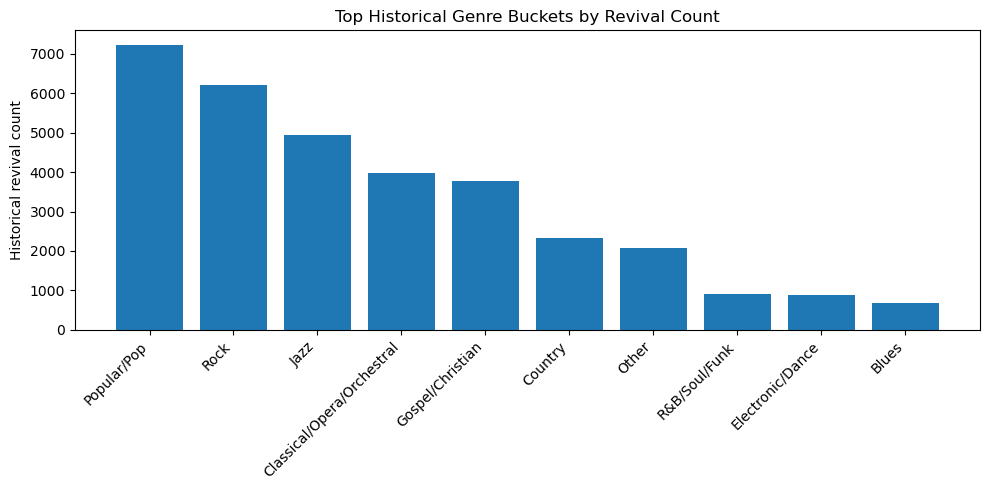

In [7]:
# Figure 1: Historical revival counts by mapped genre
loc_plot = loc_genre.sort_values("historical_genre_revival_count", ascending=False).head(10)

plt.figure()
plt.bar(loc_plot["genre_bucket"], loc_plot["historical_genre_revival_count"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Historical revival count")
plt.title("Top Historical Genre Buckets by Revival Count")
plt.tight_layout()
plt.show()

In [8]:
# Screenshot 3: Spotify genre summary
spotify_genre[["genre_bucket", "track_count", "matched_track_count", "total_streams", "streams_share"]]

KeyError: "['matched_track_count'] not in index"

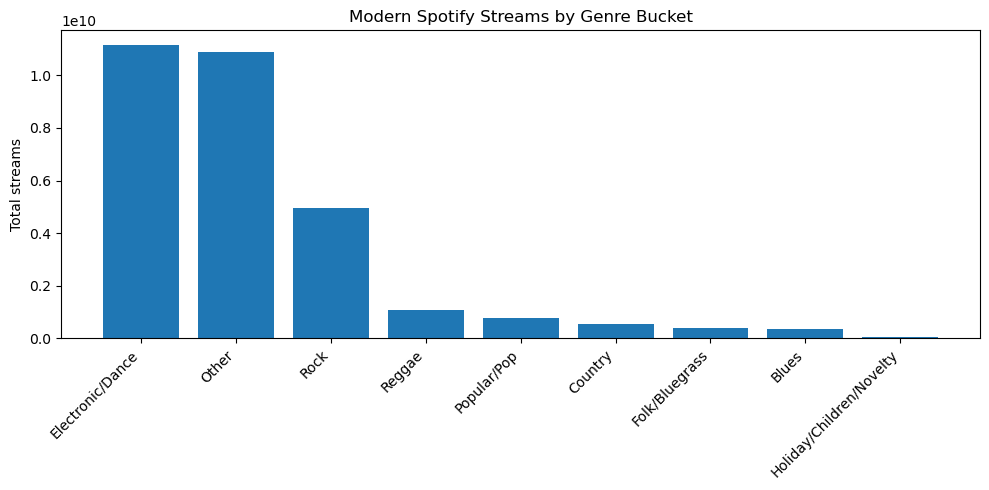

In [ ]:
# Figure 2: Spotify total streams by genre bucket
spotify_plot = spotify_genre.sort_values("total_streams", ascending=False)

plt.figure()
plt.bar(spotify_plot["genre_bucket"], spotify_plot["total_streams"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Total streams")
plt.title("Modern Spotify Streams by Genre Bucket")
plt.tight_layout()
plt.show()

In [ ]:
# Screenshot 4: Cross-era comparison table
cross[[
    "genre_bucket",
    "historical_genre_revival_count",
    "total_streams",
    "streams_share",
    "historical_revival_rank",
    "streams_rank",
    "rank_gap_streams_vs_history"
]].sort_values("historical_genre_revival_count", ascending=False)

,genre_bucket,historical_genre_revival_count,total_streams,streams_share,historical_revival_rank,streams_rank,rank_gap_streams_vs_history
11,Popular/Pop,7229,7.871516e+08,0.026040,1.0,5.0,4.0
14,Rock,6194,4.962599e+09,0.164170,2.0,3.0,1.0
8,Jazz,4926,NaN,NaN,3.0,NaN,NaN
1,Classical/Opera/Orchestral,3978,NaN,NaN,4.0,NaN,NaN
5,Gospel/Christian,3770,NaN,NaN,5.0,NaN,NaN
2,Country,2319,5.248732e+08,0.017364,6.0,6.0,0.0
10,Other,2075,1.090563e+10,0.360774,7.0,2.0,-5.0
12,R&B/Soul/Funk,922,NaN,NaN,8.0,NaN,NaN
3,Electronic/Dance,892,1.115802e+10,0.369123,9.0,1.0,-8.0
0,Blues,690,3.700686e+08,0.012242,10.0,8.0,-2.0


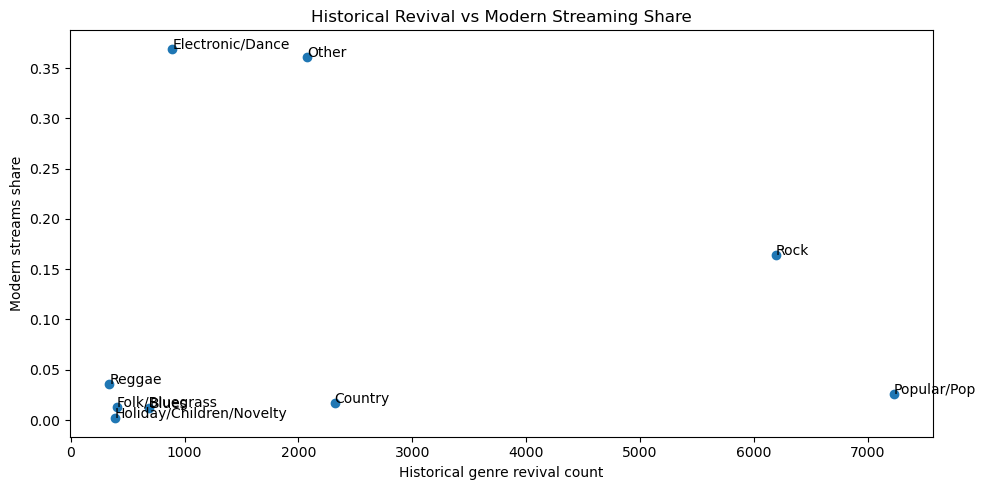

In [ ]:
# Figure 3: Cross-era comparison (excluding rows with missing streams)
cross_plot = cross.dropna(subset=["total_streams"]).copy()

plt.figure()
plt.scatter(cross_plot["historical_genre_revival_count"], cross_plot["streams_share"])
for _, row in cross_plot.iterrows():
    plt.annotate(row["genre_bucket"], (row["historical_genre_revival_count"], row["streams_share"]))
plt.xlabel("Historical genre revival count")
plt.ylabel("Modern streams share")
plt.title("Historical Revival vs Modern Streaming Share")
plt.tight_layout()
plt.show()

In [ ]:
# Screenshot 5: Concentration summary
concentration

,metric,value
0,spotify_track_entropy,2.604849
1,spotify_stream_entropy,2.074539
2,genre_count_in_cross_table,16.000000


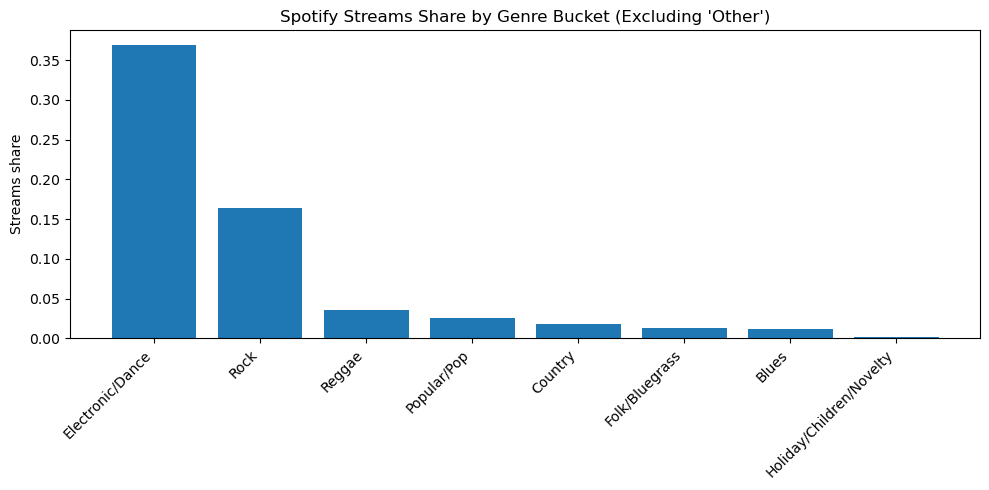

In [ ]:
# Optional figure: genre share without 'Other'
spotify_no_other = spotify_genre[spotify_genre["genre_bucket"] != "Other"].copy()

plt.figure()
plt.bar(spotify_no_other["genre_bucket"], spotify_no_other["streams_share"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Streams share")
plt.title("Spotify Streams Share by Genre Bucket (Excluding 'Other')")
plt.tight_layout()
plt.show()